# 11 · Planning and learning with tabular methods (24AIM304 Unit 4)

| method | idea | model |
|---|---|---|
| **Dyna-Q** (n planning steps) | Q-learning on real episodes + n simulated Q-learning backups per episode | running mean reward of each visited (context, configuration) |
| **Prioritized sweeping** | back up state–actions in order of \|TD error\|; propagate to the unique predecessor | same learned model |
| **Rollout algorithm** | decision-time planning: evaluate each action by Monte-Carlo rollouts of a random base policy | simulator (sample a recording of the context) |
| **MCTS / UCT** (heuristic search) | UCB1 tree policy over the configuration tree + Monte-Carlo backups | simulator |

All methods get the **same budget of real reward queries** as the model-free learners, so the
question is sample-efficiency: does planning with a learned model reach a good policy sooner?

In [1]:
%run ../common/00_config.ipynb
use_half("midsem", oracle="classical")
%run ../common/01_signal_lib.ipynb
%run ../common/02_rl_lib.ipynb
import matplotlib.pyplot as plt

K = load_json(P["results"] / "chosen_K.json")["K"]
prob = RLProblem(CFG, P, K=K)
R = CFG["rl"]
dp_value = prob.mdp("train").policy_value(np.array(load_json(P["results"] / "policies" / "dp_optimum.json")["policy"]))


def val_fn(pol):
    m = prob.evaluate(pol, "val")
    return {"val_reward": m["mean_reward"], "val_macro_f1": m["macro_f1"]}


EP = R["episodes"]
configs = {"q_learning": ("q_learning", {}), "dyna_q_n5": ("dyna_q", {"planning": 5}), "dyna_q_n20": ("dyna_q", {"planning": 20}),
           "prioritized_sweeping": ("prioritized_sweeping", {"planning": 10})}
runs = {}
for name, (algo, hp) in configs.items():
    for seed in R["seeds"]:
        t0 = time.time()
        out = run_tabular(prob.mdp("train", seed=seed), algo, EP, alpha=R["alpha"], eps_sched=R["epsilon"],
                          eval_every=2000, val_fn=val_fn, **hp)
        out["sec"] = time.time() - t0
        runs[(name, seed)] = out
    print(f"{name:22s} {np.mean([runs[(name, s)]['sec'] for s in R['seeds']]):.1f}s/run")

CirCor version 1.0.3
midsem: results -> results/midsem/ | reward oracle: classical


loaded 01_signal_lib


loaded 02_rl_lib


q_learning             8.9s/run


dyna_q_n5              11.6s/run


dyna_q_n20             20.6s/run


prioritized_sweeping   19.9s/run


In [2]:
sims = {}
for seed in R["seeds"]:
    mdp = prob.mdp("train", seed=seed)
    per_ctx = EP // K
    t0 = time.time(); sims[("mcts_uct", seed)] = mcts_policy(mdp, simulations_per_ctx=per_ctx, c=0.3); t_m = time.time() - t0
    n_actions = sum(mdp.dims)
    t0 = time.time(); sims[("rollout", seed)] = rollout_policy(mdp, sims_per_action=max(1, per_ctx // n_actions)); t_r = time.time() - t0
print(f"MCTS {t_m:.1f}s, rollout {t_r:.1f}s per seed; budget {EP} simulated reward queries each")

MCTS 4.2s, rollout 1.9s per seed; budget 60000 simulated reward queries each


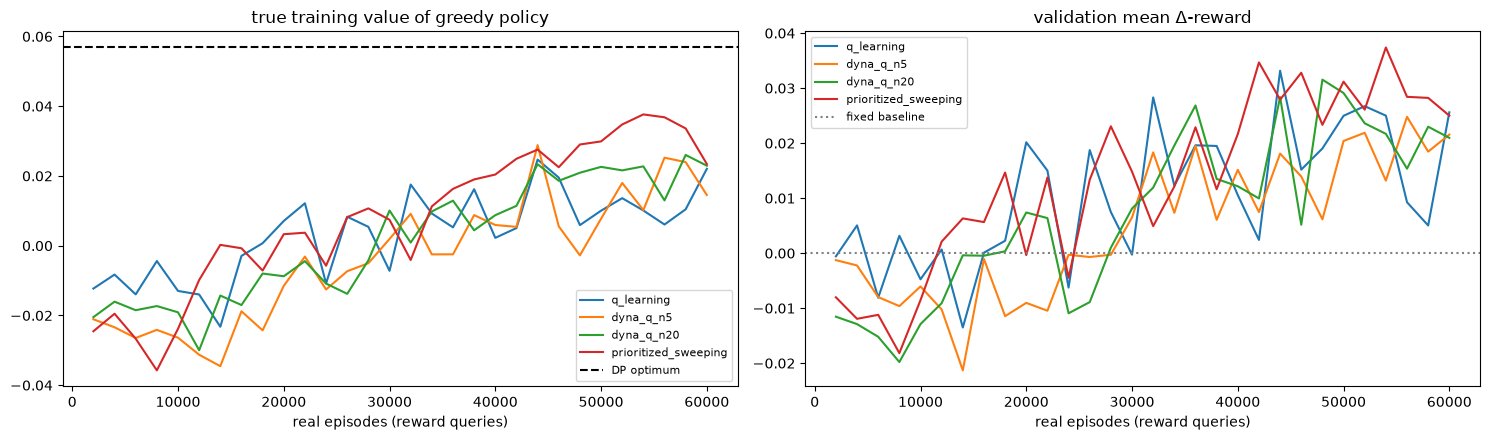

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
for name in configs:
    curves = [pd.DataFrame(runs[(name, s)]["curve"]) for s in R["seeds"]]
    for a, col in zip(ax, ["train_value", "val_reward"]):
        m = np.mean([c[col] for c in curves], 0)
        a.plot(curves[0].episode, m, label=name)
ax[0].axhline(dp_value, color="k", ls="--", label="DP optimum"); ax[0].set_title("true training value of greedy policy")
ax[1].axhline(0, color="gray", ls=":", label="fixed baseline"); ax[1].set_title("validation mean Δ-reward")
for a in ax:
    a.set_xlabel("real episodes (reward queries)"); a.legend(fontsize=8)
plt.tight_layout(); savefig(fig, "11_planning_learning_curves"); plt.show()

In [4]:
rows = []
mdp = prob.mdp("train")
for (name, seed), out in list(runs.items()) + [((k[0], k[1]), {"policy": v, "sec": np.nan}) for k, v in sims.items()]:
    pol = out["policy"]
    mv = prob.evaluate(pol, "val")
    rows.append({"method": name, "seed": seed, "fraction_of_DP_value": mdp.policy_value(pol) / dp_value,
                 **{f"val_{k}": mv[k] for k in ("mean_reward", "macro_f1", "balanced_acc", "auroc")}})
pl_tab = pd.DataFrame(rows)
pl_tab.to_csv(P["tables"] / "11_planning_results.csv", index=False)
import joblib
old = joblib.load(P["processed"] / f"tabular_runs_{P['half']}.joblib")
old.update({k: {"policy": v["policy"], "curve": v["curve"]} for k, v in runs.items()})
old.update({k: {"policy": v, "curve": []} for k, v in sims.items()})
joblib.dump(old, P["processed"] / f"tabular_runs_{P['half']}.joblib")
pl_tab.groupby("method", sort=False).agg(["mean", "std"]).drop(columns="seed").round(4)

fraction_of_DP_value         val_mean_reward         val_macro_f1         val_balanced_acc         val_auroc        
                                     mean     std            mean     std         mean     std             mean     std      mean     std
method                                                                                                                                   
q_learning                         0.3878  0.0528          0.0256  0.0105       0.6466  0.0154           0.6831  0.0145    0.7484  0.0320
dyna_q_n5                          0.2557  0.1023          0.0216  0.0110       0.6392  0.0135           0.6796  0.0197    0.7450  0.0191
dyna_q_n20                         0.4036  0.2281          0.0210  0.0068       0.6214  0.0364           0.6581  0.0294    0.7384  0.0146
prioritized_sweeping               0.4125  0.1414          0.0250  0.0165       0.6400  0.0407           0.6791  0.0329    0.7436  0.0345
mcts_uct                           0.7762  0.1684          0.0384  0.0066       0.6388  0.0092           0.6778  0.0082    0.7582  0.0196
rollout                            0.7703  0.0252          0.0414  0.0062       0.6429  0.0160           0.6759  0.0163    0.7717  0.0192